In [1]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ============================================================
# # 1D lattice stochastic reaction-diffusion (Gillespie / SSA)
# #
# # Species: A_i, B_i on sites i=0..L-1 (periodic boundary)
# #
# # Reactions at each site i:
# #   (1) A + B -> 2A        rate k * A_i * B_i      (A_i += 1, B_i -= 1)
# #   (2) A -> ∅             rate muA * A_i          (A_i -= 1)
# #   (3) B -> 2B            rate betaB * B_i        (B_i += 1)
# #   (4) B -> ∅             rate deltaB * B_i       (B_i -= 1)
# #
# # Diffusion events:
# #   A_i -> A_{i±1}         rate DA * A_i per direction
# #   B_i -> B_{i±1}         rate DB * B_i per direction
# #
# # Outputs:
# #   - time series of mean densities ā(t), b̄(t)
# #   - closure error ε(t) = <AB> - <A><B>
# #   - optional space-time heatmaps for A and B
# #
# # Notes:
# # - If betaB > deltaB, B has net growth and can explode unless A consumes it enough.
# # - For clean "mean-field breakdown" demos, often use bounded B (immigration-death or logistic),
# #   but this implements exactly what you asked.
# # ============================================================

# # -----------------------------
# # Parameters (edit these)
# # -----------------------------
# L = 200                 # lattice size
# T = 200.0               # end time
# seed = 0

# k = 0.02                # A+B -> 2A
# muA = 0.2               # A death

# betaB = 0.15            # B birth (B -> 2B)
# deltaB = 0.14           # B death

# DA = 0.5                # A diffusion coefficient
# DB = 0.5                # B diffusion coefficient

# # initial conditions
# A0 = np.zeros(L, dtype=np.int32)
# B0 = np.full(L, 20, dtype=np.int32)

# # seed a small A cluster in the middle
# A0[L//2 - 2:L//2 + 3] = 5

# # recording
# dt_sample = 0.1         # record every dt_sample time units
# record_fields = True    # store snapshots for heatmaps (can be memory heavy)
# max_snaps = 2000        # safety cap

# # -----------------------------
# # Helpers
# # -----------------------------
# def left(i):  return (i - 1) % L
# def right(i): return (i + 1) % L

# rng = np.random.default_rng(seed)

# # -----------------------------
# # Initialize
# # -----------------------------
# A = A0.copy()
# B = B0.copy()

# t = 0.0
# next_sample = 0.0

# ts = []
# Abar = []
# Bbar = []
# ABbar = []
# eps = []  # <AB> - <A><B>

# snap_times = []
# A_snaps = []
# B_snaps = []

# def record(now):
#     ts.append(now)
#     a = A.mean()
#     b = B.mean()
#     ab = (A * B).mean()
#     Abar.append(a)
#     Bbar.append(b)
#     ABbar.append(ab)
#     eps.append(ab - a*b)
#     if record_fields and len(A_snaps) < max_snaps:
#         snap_times.append(now)
#         A_snaps.append(A.copy())
#         B_snaps.append(B.copy())

# record(0.0)

# # -----------------------------
# # SSA loop
# # -----------------------------
# # We'll compute per-site propensities and sample events from the global sum.
# # For simplicity (and because L isn't huge), we recompute propensities each step.
# # For larger L, you'd want an indexed / partial update scheme.

# while t < T:
#     # propensities per site for reactions
#     prop_react1 = k * A * B                 # A+B->2A
#     prop_react2 = muA * A                   # A death
#     prop_react3 = betaB * B                 # B birth
#     prop_react4 = deltaB * B                # B death

#     # diffusion propensities per site, per direction
#     prop_Ad = DA * A                        # A hop left
#     prop_Bd = DB * B                        # B hop left
#     # right hops have same rate
#     # total propensity:
#     a0 = (prop_react1.sum() + prop_react2.sum() + prop_react3.sum() + prop_react4.sum()
#           + 2.0 * prop_Ad.sum() + 2.0 * prop_Bd.sum())

#     if a0 <= 0.0:
#         # absorbing state
#         break

#     # time to next event
#     dt = -np.log(rng.random()) / a0
#     t_new = t + dt

#     # record at regular times by "strobing"
#     while next_sample <= min(t_new, T):
#         # advance to sampling time without changing state
#         record(next_sample)
#         next_sample += dt_sample

#     t = t_new
#     if t > T:
#         break

#     # choose event type and site
#     r = rng.random() * a0

#     # cumulative blocks
#     s1 = prop_react1.sum()
#     if r < s1:
#         # Reaction 1: A+B->2A
#         # pick site i proportional to prop_react1[i]
#         probs = prop_react1 / s1
#         i = rng.choice(L, p=probs)
#         if B[i] > 0:
#             A[i] += 1
#             B[i] -= 1
#         continue

#     r -= s1
#     s2 = prop_react2.sum()
#     if r < s2:
#         # Reaction 2: A death
#         probs = prop_react2 / s2
#         i = rng.choice(L, p=probs)
#         if A[i] > 0:
#             A[i] -= 1
#         continue

#     r -= s2
#     s3 = prop_react3.sum()
#     if r < s3:
#         # Reaction 3: B birth
#         probs = prop_react3 / s3
#         i = rng.choice(L, p=probs)
#         B[i] += 1
#         continue

#     r -= s3
#     s4 = prop_react4.sum()
#     if r < s4:
#         # Reaction 4: B death
#         probs = prop_react4 / s4
#         i = rng.choice(L, p=probs)
#         if B[i] > 0:
#             B[i] -= 1
#         continue

#     r -= s4
#     s5 = 2.0 * prop_Ad.sum()
#     if r < s5:
#         # A diffusion (left or right)
#         tot = prop_Ad.sum()
#         if tot <= 0:
#             continue
#         # decide direction by splitting the 2*tot block
#         dir_right = (r >= tot)
#         rr = r - (tot if dir_right else 0.0)
#         probs = prop_Ad / tot
#         i = rng.choice(L, p=probs)
#         if A[i] > 0:
#             A[i] -= 1
#             j = right(i) if dir_right else left(i)
#             A[j] += 1
#         continue

#     r -= s5
#     s6 = 2.0 * prop_Bd.sum()
#     # B diffusion
#     tot = prop_Bd.sum()
#     if tot <= 0:
#         continue
#     dir_right = (r >= tot)
#     rr = r - (tot if dir_right else 0.0)
#     probs = prop_Bd / tot
#     i = rng.choice(L, p=probs)
#     if B[i] > 0:
#         B[i] -= 1
#         j = right(i) if dir_right else left(i)
#         B[j] += 1

# # final record at T if not already
# if ts[-1] < T:
#     record(T)

# ts = np.array(ts)
# Abar = np.array(Abar)
# Bbar = np.array(Bbar)
# ABbar = np.array(ABbar)
# eps = np.array(eps)

# # -----------------------------
# # Plots
# # -----------------------------
# fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# ax[0].plot(ts, Abar, label=r'$\langle A\rangle$')
# ax[0].plot(ts, Bbar, label=r'$\langle B\rangle$')
# ax[0].set_ylabel("mean density")
# ax[0].legend()

# ax[1].plot(ts, eps, label=r'$\epsilon(t)=\langle AB\rangle-\langle A\rangle\langle B\rangle$')
# ax[1].axhline(0, linewidth=1)
# ax[1].set_xlabel("t")
# ax[1].set_ylabel("closure error")
# ax[1].legend()

# plt.tight_layout()
# plt.show()

# # -----------------------------
# # Heatmaps (optional)
# # -----------------------------
# if record_fields and len(A_snaps) > 2:
#     A_img = np.array(A_snaps)  # shape (Tsnaps, L)
#     B_img = np.array(B_snaps)

#     fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
#     im0 = ax[0].imshow(A_img, aspect="auto", origin="lower",
#                        extent=[0, L, snap_times[0], snap_times[-1]])
#     ax[0].set_ylabel("t")
#     ax[0].set_title("A(x,t)")
#     plt.colorbar(im0, ax=ax[0], fraction=0.02, pad=0.02)

#     im1 = ax[1].imshow(B_img, aspect="auto", origin="lower",
#                        extent=[0, L, snap_times[0], snap_times[-1]])
#     ax[1].set_ylabel("t")
#     ax[1].set_xlabel("site")
#     ax[1].set_title("B(x,t)")
#     plt.colorbar(im1, ax=ax[1], fraction=0.02, pad=0.02)

#     plt.tight_layout()
#     plt.show()

# print("Done. Final means: <A> =", float(A.mean()), " <B> =", float(B.mean()))
# print("Final closure error:", float((A*B).mean() - A.mean()*B.mean()))

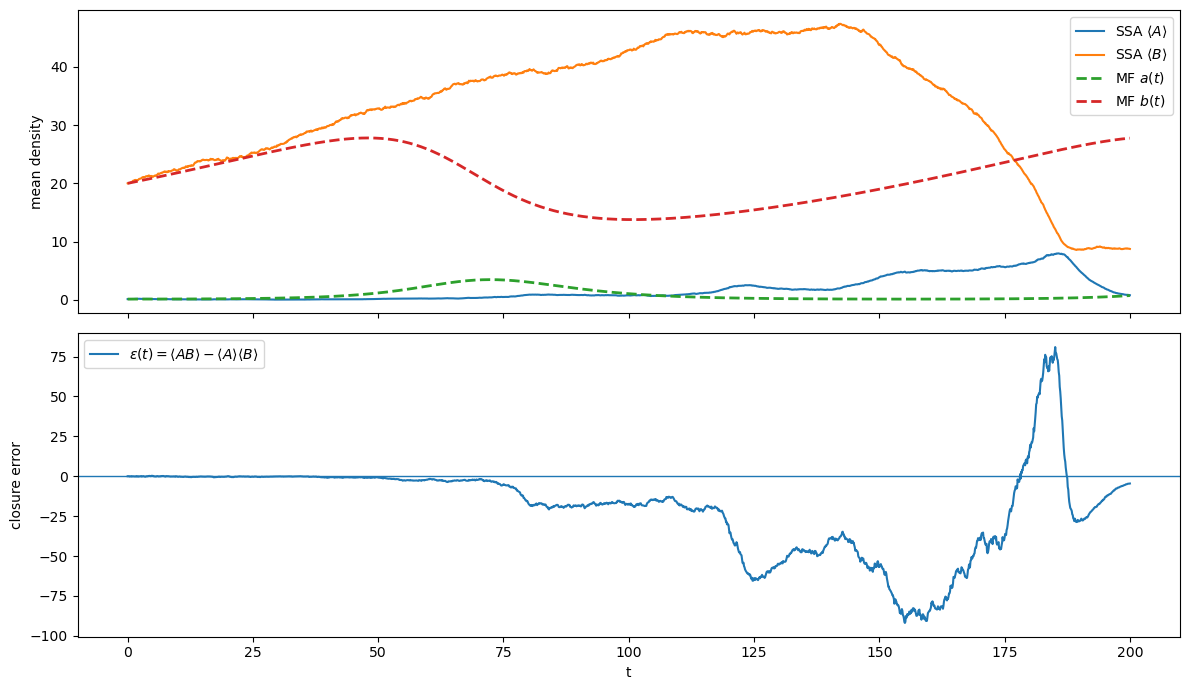

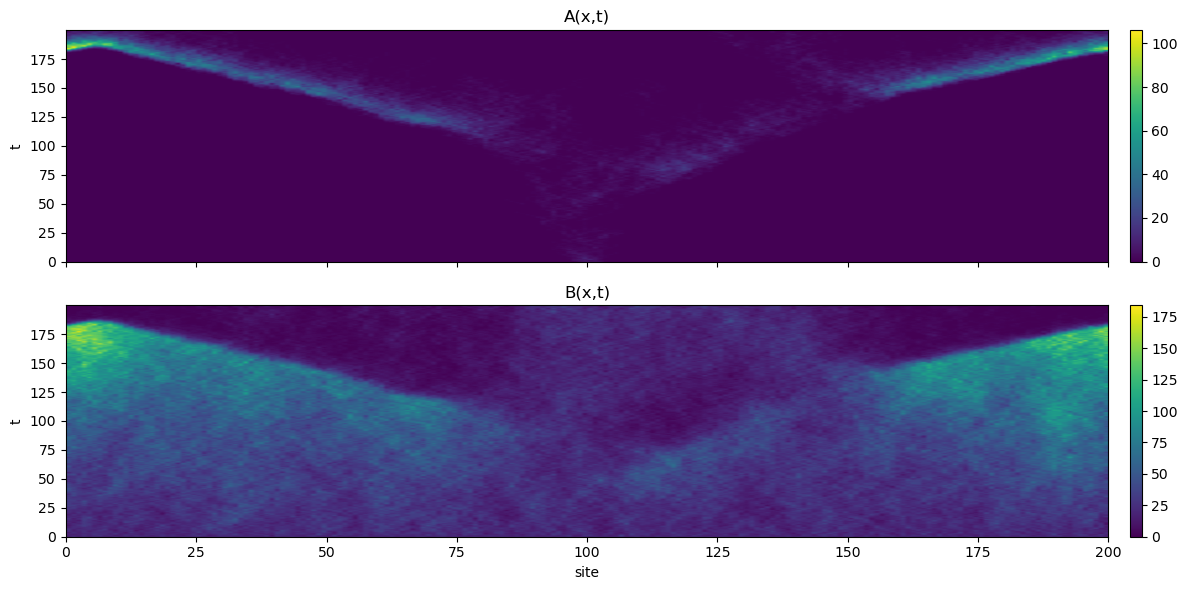

Done. Final means (SSA): <A> = 0.79  <B> = 8.74
Final means (MF):  a(T) = 0.7289287244924889  b(T) = 27.761008947962402
Final closure error: -4.5496


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1D lattice stochastic reaction-diffusion (Gillespie / SSA)
# + Naive mean-field (well-mixed closure) for spatial averages
#
# Lattice model (periodic):
#   A + B -> 2A        rate k A_i B_i
#   A -> ∅             rate muA A_i
#   B -> 2B            rate betaB B_i
#   B -> ∅             rate deltaB B_i
#   diffusion for A,B
#
# Naive MF for spatial means a(t)=<A>, b(t)=<B> uses closure <AB>≈ab:
#   da/dt = k a b - muA a
#   db/dt = betaB b - deltaB b - k a b
# ============================================================

# -----------------------------
# Parameters (edit these)
# -----------------------------
L = 200
T = 200.0
seed = 0

k = 0.01
muA = 0.2

betaB = 0.15
deltaB = 0.14

DA = 0.5
DB = 0.5

# initial conditions (lattice)
A0 = np.zeros(L, dtype=np.int32)
B0 = np.full(L, 20, dtype=np.int32)
A0[L//2 - 2:L//2 + 3] = 5

# recording
dt_sample = 0.1
record_fields = True
max_snaps = 2000

# -----------------------------
# Helpers
# -----------------------------
def left(i):  return (i - 1) % L
def right(i): return (i + 1) % L

rng = np.random.default_rng(seed)

# -----------------------------
# Initialize lattice
# -----------------------------
A = A0.copy()
B = B0.copy()

t = 0.0
next_sample = 0.0

ts = []
Abar = []
Bbar = []
ABbar = []
eps = []  # <AB> - <A><B>

snap_times = []
A_snaps = []
B_snaps = []

def record(now):
    ts.append(now)
    a = A.mean()
    b = B.mean()
    ab = (A * B).mean()
    Abar.append(a)
    Bbar.append(b)
    ABbar.append(ab)
    eps.append(ab - a*b)
    if record_fields and len(A_snaps) < max_snaps:
        snap_times.append(now)
        A_snaps.append(A.copy())
        B_snaps.append(B.copy())

record(0.0)

# -----------------------------
# SSA loop
# -----------------------------
while t < T:
    prop_react1 = k * A * B
    prop_react2 = muA * A
    prop_react3 = betaB * B
    prop_react4 = deltaB * B

    prop_Ad = DA * A
    prop_Bd = DB * B

    a0 = (prop_react1.sum() + prop_react2.sum() + prop_react3.sum() + prop_react4.sum()
          + 2.0 * prop_Ad.sum() + 2.0 * prop_Bd.sum())

    if a0 <= 0.0:
        break

    dt = -np.log(rng.random()) / a0
    t_new = t + dt

    while next_sample <= min(t_new, T):
        record(next_sample)
        next_sample += dt_sample

    t = t_new
    if t > T:
        break

    r = rng.random() * a0

    s1 = prop_react1.sum()
    if r < s1:
        probs = prop_react1 / s1
        i = rng.choice(L, p=probs)
        if B[i] > 0:
            A[i] += 1
            B[i] -= 1
        continue

    r -= s1
    s2 = prop_react2.sum()
    if r < s2:
        probs = prop_react2 / s2
        i = rng.choice(L, p=probs)
        if A[i] > 0:
            A[i] -= 1
        continue

    r -= s2
    s3 = prop_react3.sum()
    if r < s3:
        probs = prop_react3 / s3
        i = rng.choice(L, p=probs)
        B[i] += 1
        continue

    r -= s3
    s4 = prop_react4.sum()
    if r < s4:
        probs = prop_react4 / s4
        i = rng.choice(L, p=probs)
        if B[i] > 0:
            B[i] -= 1
        continue

    r -= s4
    s5 = 2.0 * prop_Ad.sum()
    if r < s5:
        tot = prop_Ad.sum()
        if tot <= 0:
            continue
        dir_right = (r >= tot)
        probs = prop_Ad / tot
        i = rng.choice(L, p=probs)
        if A[i] > 0:
            A[i] -= 1
            j = right(i) if dir_right else left(i)
            A[j] += 1
        continue

    r -= s5
    tot = prop_Bd.sum()
    if tot <= 0:
        continue
    dir_right = (r >= tot)
    probs = prop_Bd / tot
    i = rng.choice(L, p=probs)
    if B[i] > 0:
        B[i] -= 1
        j = right(i) if dir_right else left(i)
        B[j] += 1

if ts[-1] < T:
    record(T)

ts = np.array(ts)
Abar = np.array(Abar)
Bbar = np.array(Bbar)
ABbar = np.array(ABbar)
eps = np.array(eps)

# -----------------------------
# Naive mean-field ODE for spatial means
# -----------------------------
# Use Euler on the same sampling grid for easy overlay
tmf = ts.copy()
a_mf = np.empty_like(tmf)
b_mf = np.empty_like(tmf)

# MF IC from lattice means at t=0
a_mf[0] = float(A0.mean())
b_mf[0] = float(B0.mean())

for n in range(len(tmf) - 1):
    h = tmf[n+1] - tmf[n]
    a = a_mf[n]
    b = b_mf[n]
    da = (k * a * b - muA * a)
    db = ((betaB - deltaB) * b - k * a * b)
    a_mf[n+1] = max(a + h * da, 0.0)
    b_mf[n+1] = max(b + h * db, 0.0)

# -----------------------------
# Plots
# -----------------------------
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax[0].plot(ts, Abar, label=r'SSA $\langle A\rangle$')
ax[0].plot(ts, Bbar, label=r'SSA $\langle B\rangle$')
ax[0].plot(tmf, a_mf, "--", linewidth=2, label=r'MF $a(t)$')
ax[0].plot(tmf, b_mf, "--", linewidth=2, label=r'MF $b(t)$')
ax[0].set_ylabel("mean density")
ax[0].legend()

ax[1].plot(ts, eps, label=r'$\epsilon(t)=\langle AB\rangle-\langle A\rangle\langle B\rangle$')
ax[1].axhline(0, linewidth=1)
ax[1].set_xlabel("t")
ax[1].set_ylabel("closure error")
ax[1].legend()

plt.tight_layout()
plt.show()

# -----------------------------
# Heatmaps (optional)
# -----------------------------
if record_fields and len(A_snaps) > 2:
    A_img = np.array(A_snaps)
    B_img = np.array(B_snaps)

    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    im0 = ax[0].imshow(A_img, aspect="auto", origin="lower",
                       extent=[0, L, snap_times[0], snap_times[-1]])
    ax[0].set_ylabel("t")
    ax[0].set_title("A(x,t)")
    plt.colorbar(im0, ax=ax[0], fraction=0.02, pad=0.02)

    im1 = ax[1].imshow(B_img, aspect="auto", origin="lower",
                       extent=[0, L, snap_times[0], snap_times[-1]])
    ax[1].set_ylabel("t")
    ax[1].set_xlabel("site")
    ax[1].set_title("B(x,t)")
    plt.colorbar(im1, ax=ax[1], fraction=0.02, pad=0.02)

    plt.tight_layout()
    plt.show()

print("Done. Final means (SSA): <A> =", float(A.mean()), " <B> =", float(B.mean()))
print("Final means (MF):  a(T) =", float(a_mf[-1]), " b(T) =", float(b_mf[-1]))
print("Final closure error:", float((A*B).mean() - A.mean()*B.mean()))